In [23]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [24]:
#carregar imagens
montanha_bgr = cv2.imread('data/montanha.png')
lenna_bgr = cv2.imread('data/lenna.png')

#converter para HSV
montanha_hsv = cv2.cvtColor(montanha_bgr, cv2.COLOR_BGR2HSV)
lenna_rgb = cv2.cvtColor(lenna_bgr, cv2.COLOR_BGR2RGB)


In [25]:
#aplicar o stretching no HSV
def stretching_contraste_hsv(img_bgr):
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV).astype(np.float32)
    eps = np.finfo(np.float32).eps

    V = hsv[:, :, 2]
    V = (V - V.min()) * (255 / (V.max() - V.min() + eps))
    V = np.clip(V, 0, 255)

    hsv[:, :, 2] = V

    return cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)

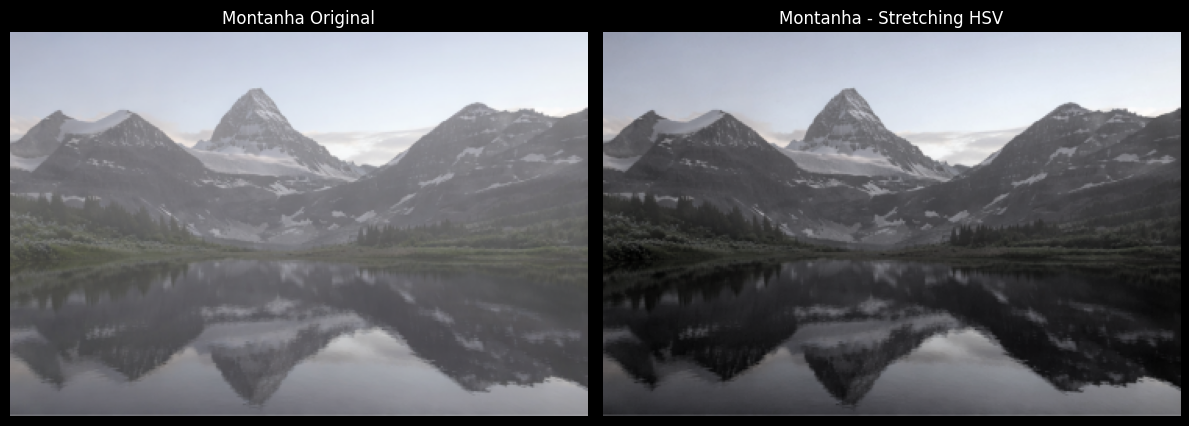

In [26]:
#aplicar o stretching no HSV
montanha_out_hsv = stretching_contraste_hsv(montanha_bgr)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(montanha_bgr, cv2.COLOR_BGR2RGB))
plt.title('Montanha Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(montanha_out_hsv)
plt.title('Montanha - Stretching HSV')
plt.axis('off')

plt.tight_layout()
plt.show()

In [27]:
#Fazendo o mesmo mas em RGB

def stretching_contraste_rgb(img_rgb):
    img = img_rgb.astype(np.float32)
    eps = np.finfo(np.float32).eps

    out = np.zeros_like(img)

    for c in range(3):
        channel = img[:, :, c]
        out[:, :, c] = (channel - channel.min()) * (255 / (channel.max() - channel.min() + eps))

    np.clip(out, 0, 255, out=out)
    return out.astype(np.uint8)

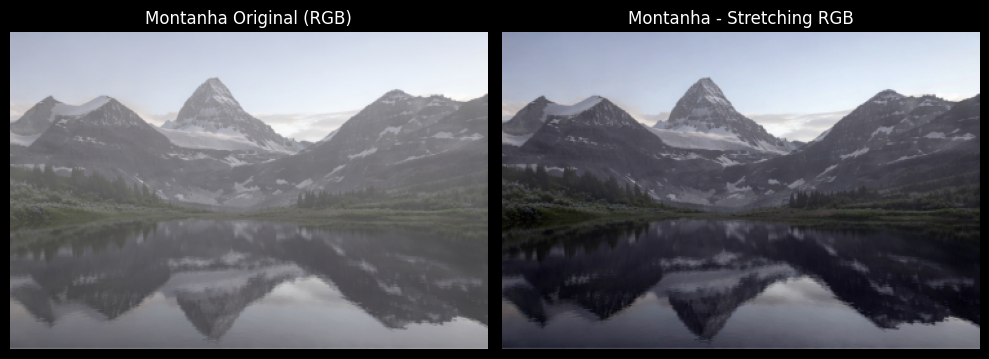

In [28]:
#mostrando resultados em RGB
montanha_rgb = cv2.cvtColor(montanha_bgr, cv2.COLOR_BGR2RGB)
montanha_out_rgb = stretching_contraste_rgb(montanha_rgb)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(montanha_rgb)
plt.title('Montanha Original (RGB)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(montanha_out_rgb)
plt.title('Montanha - Stretching RGB')
plt.axis('off')

plt.tight_layout()
plt.show()

In [29]:
def clip_contraste(imagem, p_min=2, p_max=98):
    imagem = imagem.astype(np.float32)
    canais = []

    for c in range(imagem.shape[2]):
        canal = imagem[:, :, c].copy()

        pmin = np.percentile(canal, p_min)
        pmax = np.percentile(canal, p_max)

        np.clip(canal, pmin, pmax, out=canal)

        canal = (canal - pmin) * (255 / (pmax - pmin + np.finfo(np.float32).eps))

        np.clip(canal, 0, 255, out=canal)

        canais.append(canal.astype(np.uint8))

    return np.dstack(canais)

In [30]:
# sem for e sem vetor
# def clip_contraste(imagem, p_min=2, p_max=98):
#     imagem = imagem.astype(np.float32)
#
#     pmin = np.percentile(imagem, p_min, axis=(0, 1), keepdims=True)
#     pmax = np.percentile(imagem, p_max, axis=(0, 1), keepdims=True)
#
#     imagem = np.clip(imagem, pmin, pmax)
#
#     imagem = (imagem - pmin) * (255 / (pmax - pmin + np.finfo(np.float32).eps))
#
#     imagem = np.clip(imagem, 0, 255)
#
#     return imagem.astype(np.uint8)

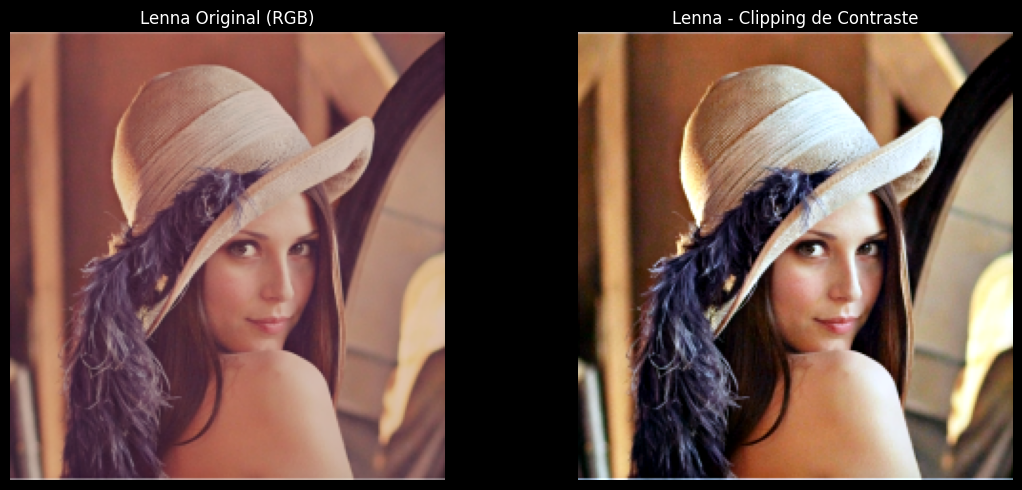

In [31]:
image = clip_contraste(lenna_rgb)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(lenna_rgb)
plt.title('Lenna Original (RGB)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(image)
plt.title('Lenna - Clipping de Contraste')
plt.axis('off')

plt.tight_layout()
plt.show()

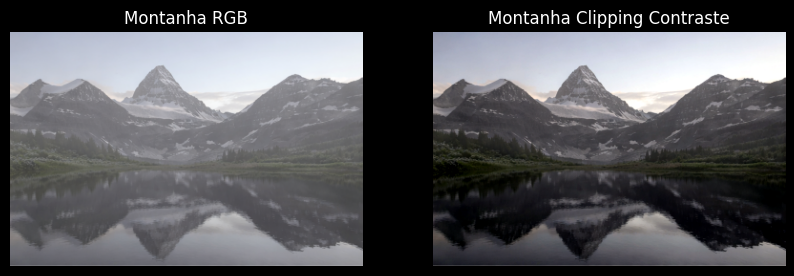

In [32]:
img = clip_contraste(montanha_rgb, p_min=2, p_max=98)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(montanha_rgb)
plt.title('Montanha RGB')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img)
plt.title('Montanha Clipping Contraste')
plt.axis('off')
plt.show()

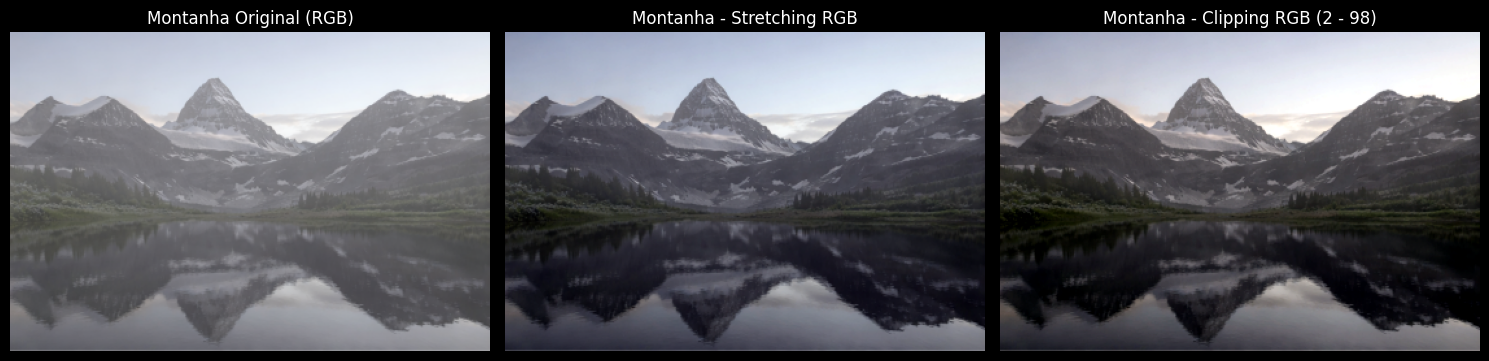

In [33]:
imagem_rgb = clip_contraste(montanha_out_rgb)
p_min,p_max=2,98

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(montanha_rgb)
plt.title('Montanha Original (RGB)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(montanha_out_rgb)
plt.title('Montanha - Stretching RGB')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(imagem_rgb)
plt.title(f'Montanha - Clipping RGB ({p_min} - {p_max})')
plt.axis('off')

plt.tight_layout()
plt.show()